In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Problem 2

In [80]:
df1 = pd.read_csv('/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps2mult1.csv', header= None)
df1

,0,1,2
0,-2.000000,0.794694,-1.200868
1,-1.959596,0.226122,-2.343926
2,-1.919192,-1.439440,-7.622010
3,-1.878788,-0.857107,-5.104197
4,-1.838384,0.221476,-2.334743
...,...,...,...
95,1.838384,-0.634426,2.318936
96,1.878788,1.151839,8.380589
97,1.919192,-0.542000,3.600311
98,1.959596,0.660490,7.019233


### a)

In [81]:
df.columns = ['X1', 'X2', 'Y']
X1 = df['X1'].values
X2 = df['X2'].values
Y = df['Y'].values

n = len(Y)
H = np.column_stack((np.ones(n), X1, X2))
Beta_hat = np.linalg.inv(H.T @ H) @ (H.T @ Y)
print(f'Beta0: {Beta_hat[0]}')
print(f'Beta1: {Beta_hat[1]}')
print(f'Beta2: {Beta_hat[2]}')




Beta0: 0.9876808031335288
Beta1: 2.0775010150046374
Beta2: 3.0161893641291164


### b)

In [82]:
Y_hat = H @ Beta_hat

e = Y - Y_hat

print("Minimum residual:", np.min(e))
print("Maximum residual:", np.max(e))



Minimum residual: -0.9288486791979174
Maximum residual: 1.255866470466482


### c)

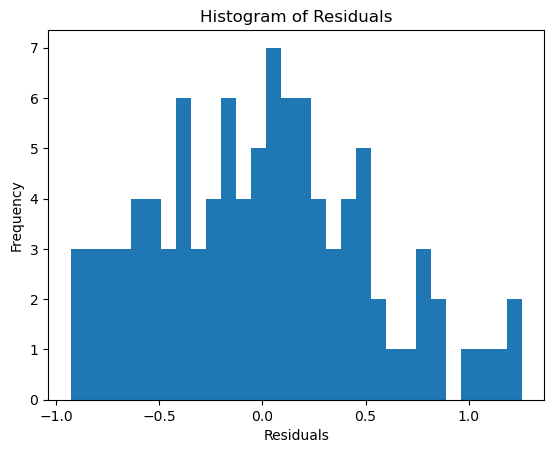

In [83]:
plt.hist(e, bins = 30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

## Problem 3

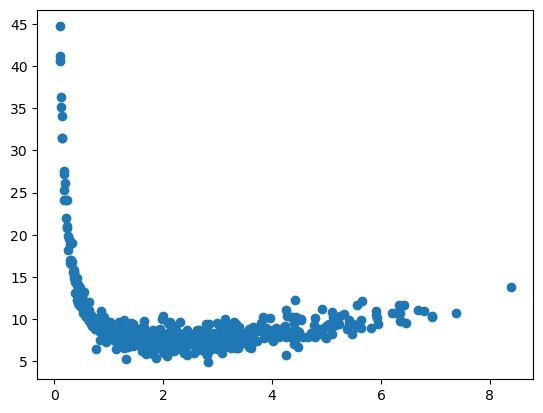

In [84]:
df2 = pd.read_csv('/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps2mult2.csv', header= None)
plt.plot(df2[0], df2[1], 'o')

### a)

In [85]:
# Since our graph is exponential, we are going to apply yi = beta[0] + beta[1]*x + beta[2]*(1/x)

Y2 = np.array(df2[1])
X2_normal = np.array(df2[0])
X2_inverse = 1/X2_normal
X2 = np.c_[np.ones(len(Y2)), np.c_[X2_normal, X2_inverse]]

Beta_hat2 = np.linalg.inv(X2.T @ X2) @ (X2.T @ Y2)

print(f'Beta0: {Beta_hat2[0]}')
print(f'Beta1: {Beta_hat2[1]}')
print(f'Beta2: {Beta_hat2[2]}')



Beta0: 3.4425418309382056
Beta1: 1.0024625080898857
Beta2: 4.045378830871115


### b)

In [86]:
Y_hat = X2 @ Beta_hat2

e2 = Y2 - Y_hat

print("Minimum residual:", np.min(e2))
print("Maximum residual:", np.max(e2))

Minimum residual: -3.0523854235036563
Maximum residual: 3.4527874227260043


### C)

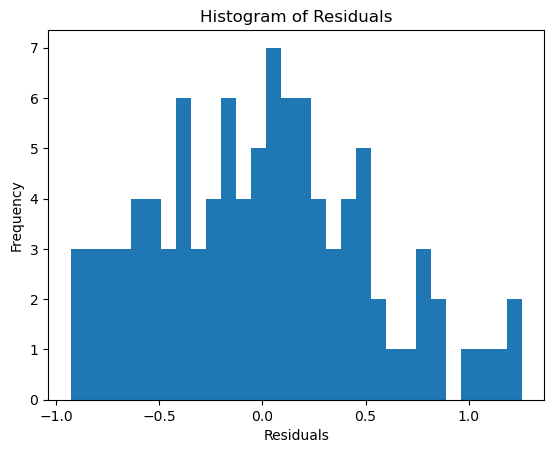

In [87]:
plt.hist(e, bins = 30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

## Problem 4

In [88]:
df3 = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps2mult3.csv")
df3

,1.98673470877111,3.88058286393061,5.53996776820034
0,0.565305,1.304131,1.092732
1,-3.598600,-1.892916,-0.653892
2,-2.142767,4.632153,43.686741
3,0.553690,-0.900932,2.651475
4,-4.748688,2.481300,47.441461
...,...,...,...
194,-1.956283,1.719559,11.468632
195,-3.593261,-3.519690,-3.588388
196,0.516270,2.945634,6.513927
197,1.440949,0.166126,3.058118


In [89]:
df3.columns = ['X', 'Y', 'Z']

X = df3['X'].values
Y = df3['Y'].values
Z = df3['Z'].values

n = len(Z)

X_sq = X**2
Y_sq = Y**2
XY = X*Y


H = np.column_stack((
    np.ones(n),
    X,
    Y,
    X_sq,
    Y_sq,
    XY
))



### a)

In [90]:
print("β estimates:", beta_hat)

β estimates: [ 9.98654856  2.52937451 -0.83151615  5.87092363]


In [91]:
beta_hat3 = np.linalg.inv(H.T @ H) @ (H.T @ Z)
res = Z - (H @ beta_hat3)

### b)

In [92]:
print("Minimum residual: ", np.min(res))
print("Maximum residual: ", np.max(res))

Minimum residual:  -0.0991525173313832
Maximum residual:  0.1045451713568335


### C)

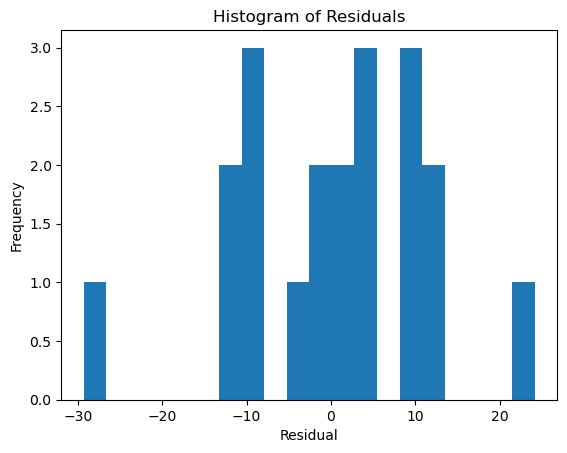

In [93]:
plt.hist(residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

## Problem 6

In [94]:
df6 = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps2norm1.csv")
df6.columns = ["X1","X2","X3","Y"]

print(df6.head())

         X1        X2        X3         Y
0  0.556531  0.632512  0.830847  9.919968
1  0.140140  0.958269  0.418317  5.573671
2  0.285723  0.886354  0.082031  2.500926
3  0.555369  0.523184  0.176028  5.496685
4  0.025131  0.715916  0.180961  1.774766


In [95]:
X1 = df6["X1"].values
X2 = df6["X2"].values
X3 = df6["X3"].values
Y  = df6["Y"].values

n = len(Y)

X = np.column_stack((np.ones(n), X1, X2, X3))

## a)

In [96]:
G = X.T @ X
det_G = np.linalg.det(G)

print("Det_G: ", det_G)

Det_G:  2089.265759343036


### B)

In [97]:
beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ Y)

print("β0 =", beta_hat[0])
print("β1 =", beta_hat[1])
print("β2 =", beta_hat[2])
print("β3 =", beta_hat[3])

β0 = 3.7886240159090745
β1 = 2.0701321734284237
β2 = -1.8019270228208029
β3 = 2.9421901451009735


### C)

In [98]:
Y_hat = X @ beta_hat
residuals = Y - Y_hat

# Residual Sum of Squares
SSres = residuals.T @ residuals

# Residual Sum of Squares - we have 2 parameters
p = 4
MSRes = SSres / (n - p)

print("SSres: ", SSres)
print("MSRes: ", MSRes)




SSres:  250.37735094813158
MSRes:  5.563941132180702


### D)

In [99]:
sigma2_MLE = SSres / n

print("σ^2_MLE =", sigma2_MLE)

σ^2_MLE = 5.109741856084318


### E)

In [100]:
ratio = sigma2_MLE / MSRes

print("ratio =", ratio)

ratio = 0.9183673469387755


In [101]:
# theoretical value - (n- p) / n


val = (n- 4) / n

print(val)

0.9183673469387755


Yes, the theoretical value agrees with the computational value. The ratio is less than 1 since σ MLE (squared) is biased but MSres is unbiased, which is why regression uses 
SSres/ n-p and not SSres/n

## Problem 7

In [102]:
Niter = 50000

results = []

for _ in range(Niter):

    X1 = np.random.normal(0,1,N)
    X2 = np.random.normal(0,1,N)
    X3 = np.random.normal(0,1,N)

    epsilon = np.random.normal(0, np.sqrt(300), N)

    X = np.column_stack((np.ones(N), X1, X2, X3))

    Y = X @ beta_true + epsilon

    beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ Y)

    Y_hat = X @ beta_hat
    residuals = Y - Y_hat

    SSRes = residuals.T @ residuals
    MSRes = SSRes / (N-4)
    sigma2_MLE = SSRes / N

    results.append([
        beta_hat[0],
        beta_hat[1],
        beta_hat[2],
        beta_hat[3],
        MSRes,
        sigma2_MLE
    ])

In [103]:
results = np.array(results)

averages = results.mean(axis=0)

print("Average beta0_hat =", averages[0])
print("Average beta1_hat =", averages[1])
print("Average beta2_hat =", averages[2])
print("Average beta3_hat =", averages[3])
print("Average MSRes =", averages[4])
print("Average sigma2_MLE =", averages[5])

Average beta0_hat = 2.0225985197272447
Average beta1_hat = 4.019091899316322
Average beta2_hat = 4.982200826244387
Average beta3_hat = 6.966326417505147
Average MSRes = 299.3449199194188
Average sigma2_MLE = 239.47593593553336


## Interpretation

The simulation was repeated **50,000 times** and the averages of  
$\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3, MS_{Res}$, and $\hat{\sigma}^2_{MLE}$ were computed.

The true parameters used to generate the data were

$$
(\beta_0,\beta_1,\beta_2,\beta_3) = (2,4,5,7)
$$

The average estimated coefficients were very close to these values. This confirms the theoretical result that the **least squares estimators are unbiased**, meaning

$$
E[\hat{\beta}] = \beta.
$$

The true noise variance is

$$
\sigma^2 = 300.
$$

The statistic

$$
MS_{Res} = \frac{SS_{Res}}{N-p}
$$

is an **unbiased estimator** of $\sigma^2$, so its average should be close to **300**, which agrees with the simulation.

The maximum likelihood estimator

$$
\hat{\sigma}^2_{MLE} = \frac{SS_{Res}}{N}
$$

is **biased**. Its expected value is

$$
E[\hat{\sigma}^2_{MLE}] = \sigma^2\frac{N-p}{N}.
$$

With $N=20$ and $p=4$,

$$
E[\hat{\sigma}^2_{MLE}] = 300 \cdot \frac{16}{20} = 240.
$$

The simulation average should therefore be close to **240**, which confirms the theoretical result.